In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import sys
import os
import traceback
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import matlab.engine
from scipy.spatial.distance import cdist
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import RMSprop

from extractor_api import ExtractorAPI
from dataset_api import DatasetAPI

mateng = None

matplotlib.rcParams['font.family'] = "Times New Roman"

2024-08-30 18:18:00.987934: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-30 18:18:00.987997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-30 18:18:00.989152: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-30 18:18:00.995966: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-30 18:18:01.660041: W tensorflow/compiler/tf2

In [2]:
import dataset_preparation
import deep_learning_models

importlib.reload(dataset_preparation)
importlib.reload(deep_learning_models)

from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import NPairNet, identity_loss

In [4]:
ROOT_DIRECTORY = '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY = '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/lora_rffi_working'
MATLAB_SESSION_ID = 'fp_workflow'

dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=False)
extractor_api = ExtractorAPI()

In [20]:
def evaluate_fingerprint_similarity_all(dev_range, fingerprints_all, rssis_all, ref_device_idx, ref_epoch_idx, epoch_count, show_heatmap = False):
    # Extract reference FPs for each RX device
    ref_fps = []
    for rx_i in np.arange(len(fingerprints_all)):
        ref_fps.append(fingerprints_all[rx_i][ref_device_idx, ref_epoch_idx, :, :])
    
    # Initialize a matrix to store average distances with respect to reference fingerprints
    avg_distances = np.zeros((len(dev_range), epoch_count))

    # Compute average Euclidean distance with respect to reference fingerprints for each device and epoch
    for i in np.arange(avg_distances.shape[0]):
        for j in np.arange(avg_distances.shape[1]):
            rx_distances = []
            rx_weights = []
            for rx_i in np.arange(len(fingerprints_all)):
                # Extract the K fingerprints for device i at epoch j
                data = fingerprints_all[rx_i][i, j, :, :]

                # Compute the Euclidean distances between reference fingerprints and current fingerprints
                distances = cdist(ref_fps[rx_i], data, 'euclidean')

                # Extract the K RSSI values for device i at epoch j and compute an average value
                rssis = rssis_all[rx_i][i, j, :]

                rx_distances.append(np.mean(distances))
                rx_weights.append(dataset_api.rssi_to_weight(np.mean(rssis)))

            # rx_weights = [0.5, 0.5, 0.5, 0.5]
            
            avg_distances[i, j] = sum(d * w for d, w in zip(rx_distances, rx_weights))/len(rx_weights)

    device_distances = np.mean(avg_distances, axis=1)

    if show_heatmap:
        # Plot the heatmaps side by side
        _, axes = plt.subplots(1, 2, figsize=(20, 8))

        # Plot the heatmap
        sns.heatmap(avg_distances, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Average Euclidean Distance with Respect to Reference'}, yticklabels=dev_range, ax=axes[0])
        axes[0].set_title(f'Average Euclidean Distance of Fingerprints Across Devices and Epochs\n(Reference: device={dev_range[ref_device_idx]}, epoch={ref_epoch_idx})')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Device')

        # Plot the bar chart
        axes[1].bar(np.arange(avg_distances.shape[0]), device_distances)
        axes[1].set_title(f"Device fingerprint comparison\n(Reference: device={dev_range[ref_device_idx]}, epoch={ref_epoch_idx+1})")
        axes[1].set_xlabel('Device')
        axes[1].set_ylabel('Average Distance')

    device_distances.sort()

    return avg_distances, device_distances[0], device_distances[1]
        
def evaluate_fingerprint_similarity(dev_range, fingerprints, ref_device_idx, ref_epoch_idx, show_heatmap = False):
    N, M, K, D = fingerprints.shape

    # Extract reference fingerprints at device_idx and epoch_idx
    reference_fingerprints = fingerprints[ref_device_idx, ref_epoch_idx, :, :]

    # Initialize a matrix to store average distances with respect to reference fingerprints
    avg_distances = np.zeros((N, M))

    # Compute average Euclidean distance with respect to reference fingerprints for each device and epoch
    for i in range(N):
        for j in range(M):
            # Extract the K fingerprints for device i at epoch j
            data = fingerprints[i, j, :, :]
            # Compute the Euclidean distances between reference fingerprints and current fingerprints
            distances = cdist(reference_fingerprints, data, 'euclidean')
            # Average the distances
            avg_distance = np.mean(distances)
            avg_distances[i, j] = avg_distance

    device_distances = np.mean(avg_distances, axis=1)

    if show_heatmap:
        # Plot the heatmaps side by side
        _, axes = plt.subplots(1, 2, figsize=(20, 8))

        # Plot the heatmap
        sns.heatmap(avg_distances, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Average Euclidean Distance with Respect to Reference'}, yticklabels=dev_range, ax=axes[0])
        axes[0].set_title(f'Average Euclidean Distance of Fingerprints Across Devices and Epochs\n(Reference: device={dev_range[ref_device_idx]}, epoch={ref_epoch_idx})')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Device')

        # Plot the bar chart
        axes[1].bar(np.arange(avg_distances.shape[0]), device_distances)
        axes[1].set_title(f"Device fingerprint comparison\n(Reference: device={dev_range[ref_device_idx]}, epoch={ref_epoch_idx+1})")
        axes[1].set_xlabel('Device')
        axes[1].set_ylabel('Average Distance')

    device_distances.sort()

    return avg_distances, device_distances[0], device_distances[1]

In [21]:
def run_training(data_config, model_config, aug_config, aug_on):
    # Retrieve information about the dataset: paths to dataset files, node IDs, sampling rate
    dataset_train_path, _, model_path, node_ids_train, _, samp_rate = dataset_api.load_dataset_info(data_config['dataset_name'], data_config['rx_name'], None)

    # Retrieve (and optionally augment) the data to produce data, label variables
    if aug_on:
        data, label, rssi = dataset_api.load_augmented_dataset(dataset_train_path, samp_rate, aug_config, shuffle=True)
    else:
        data, label, rssi = dataset_api.load_raw_dataset(dataset_train_path, shuffle=True)

    # Filter the dataset (pick specified nodes & frames)
    data, label, rssi = dataset_api.filter_dataset(data, label, rssi, node_ids_train, np.arange(0, data_config['frame_count_train']))

    # Filter the dataset (pick only a specified number of frames)
    data = data[:, 0:data_config['samples_count']]

    # Add AWGN
    # data = awgn(data, np.arange(aug_config['awgn'][0][0], aug_config['awgn'][0][1]))

    # Train the model
    feature_extractor, history = extractor_api.train(data, label, node_ids_train, model_config, save_path=model_path)

    return feature_extractor, history

def produce_fingerprints(feature_extractor, data_config, model_config, node_ids_epoch, epochs_override):
    # Retrieve information about the dataset: paths to dataset files, node IDs, sampling rate
    _, dataset_epoch_paths, model_path, _, _, samp_rate = dataset_api.load_dataset_info(data_config['dataset_name'], data_config['rx_name'], epochs_override)

    # Load the model from the file if not available
    if not feature_extractor:
        feature_extractor = load_model(model_path, compile=False)

    fingerprints = np.zeros(shape=(len(node_ids_epoch), len(dataset_epoch_paths), data_config['frame_count_epoch'], model_config['fp_len']))
    rssis = np.zeros(shape=(len(node_ids_epoch), len(dataset_epoch_paths), data_config['frame_count_epoch']))

    print(len(dataset_epoch_paths))

    # Extract fingerprint for every epoch
    for m in np.arange(len(dataset_epoch_paths)):
        label = []
        try:
            print('.', end='')

            # Load all frames/samples for a given epoch
            data, label, rssi = dataset_api.load_raw_dataset(dataset_epoch_paths[m], shuffle=False)

            # Filter the dataset (pick specified nodes & frames)
            data, label, rssi = dataset_api.filter_dataset(data, label, rssi, dev_range=node_ids_epoch, pkt_range=np.arange(0, data_config['frame_count_epoch']))

            # Filter the dataset (pick only a specified number of frames)
            data = data[:, 0:data_config['samples_count']]

            # Add AWGN
            # data = awgn(data, np.arange(aug_config['awgn'][0][0], aug_config['awgn'][0][1]))

            # Extract fingerprints from the trained model
            data_fps = extractor_api.run(feature_extractor, data, model_config)

            # Reshape the fingerprints for easier retrieval
            data_fps_reshaped = data_fps.reshape(len(node_ids_epoch), int(data.shape[0]/len(node_ids_epoch)), data_fps.shape[1])
            rssi_reshaped = rssi.reshape(len(node_ids_epoch), int(data.shape[0]/len(node_ids_epoch)))

            # Save fingerprints for further analysis
            for n in np.arange(data_fps_reshaped.shape[0]):
                for k in np.arange(data_fps_reshaped.shape[1]):
                    fingerprints[n, m, k, :] = data_fps_reshaped[n, k, :]
                    rssis[n, m, k] = rssi_reshaped[n, k]
        except Exception as e:
            print(dataset_epoch_paths[m])
            print(e)
            traceback.print_exc()

    return samp_rate, fingerprints, rssis

def generate_figure_temporal_stability(fp_maps, tx_node_names, epoch_count):
    fp_maps_normalized = MinMaxScaler(feature_range=(0, 1)).fit_transform(fp_maps.reshape(-1, 1))
    fp_maps = fp_maps_normalized.reshape(fp_maps.shape)

    plt.figure(figsize=(10, 8), dpi=100)
    plt.rcParams['font.family'] = 'Serif'
    plt.rcParams['font.serif'] = ['Times New Roman']

    y_ticks_vals = []
    y_ticks_labels = []
    for node_i, fp_map in enumerate(fp_maps):
        tx_node_name = f"Node ID: {tx_node_names[node_i]}"
        tx_node_fp_distances = fp_map[node_i, :]

        y_ticks_vals.append(node_i)
        y_ticks_labels.append(tx_node_name)

        plt.plot(tx_node_fp_distances + node_i, label=tx_node_name, color='black')

    # plt.legend()
    plt.yticks(ticks=y_ticks_vals, labels=y_ticks_labels)

def run_fingerprinting_single(feature_extractor, data_config, model_config, node_ids_epoch, epochs_override, aug_on, show_fp_heatmaps):
    # Produce fingerprints
    samp_rate, fingerprints, _ = produce_fingerprints(feature_extractor, data_config, model_config, node_ids_epoch, epochs_override)

    # Evaluate similarity of fingerprints
    fp_maps = np.zeros((len(node_ids_epoch), len(node_ids_epoch), fingerprints.shape[1]))
    fp_distances = np.zeros((len(node_ids_epoch), 2))
    
    for device_idx in np.arange(len(node_ids_epoch)):
        fp_dist_map, top1_dist, top2_dist = evaluate_fingerprint_similarity(node_ids_epoch, fingerprints, device_idx, ref_epoch_idx=0, show_heatmap=show_fp_heatmaps)
        fp_distances[device_idx, 0] = top1_dist
        fp_distances[device_idx, 1] = top2_dist

        fp_maps[device_idx, :, :] = fp_dist_map

    generate_figure_temporal_stability(fp_maps, node_ids_epoch, fingerprints.shape[1])

    # Prepare title for the plot
    fp_discrimination_figure_title = f"Dataset: {data_config['dataset_name']}, RX: {data_config['rx_name']}, Frames: [{data_config['frame_count_train']}/{data_config['frame_count_epoch']}], Samples: [{data_config['samples_count']} ({int(samp_rate/1e6)} MHz)], Augmentation: {aug_on}, Alpha: {model_config['alpha']}"

    return fp_distances, fp_discrimination_figure_title

def run_fingerprinting_all(rx_nodes, models, experiment_configs, node_ids_epoch, epochs_override, aug_on, show_fp_heatmaps):
    # Produce fingerprints for all receivers, using corresponding models
    min_epoch_count = sys.maxsize
    fingerprints_all = []
    rssis_all = []
    for i, rx_node in enumerate(rx_nodes):
        print(f"Generating eval finerprints for {rx_node}...")
        data_config, _, model_config = experiment_configs[i]
        # Samp rate is always the same, so we'll just use the last one
        samp_rate, fingerprints, rssis = produce_fingerprints(models[i], data_config, model_config, node_ids_epoch, epochs_override)
        fingerprints_all.append(fingerprints)
        rssis_all.append(rssis)

        min_epoch_count = min(min_epoch_count, fingerprints.shape[1])
        
    # Evaluate similarity of fingerprints
    fp_maps = np.zeros((len(node_ids_epoch), len(node_ids_epoch), min_epoch_count))
    fp_distances = np.zeros((len(node_ids_epoch), 2))
    for device_idx in np.arange(len(node_ids_epoch)):
        fp_dist_map, top1_dist, top2_dist = evaluate_fingerprint_similarity_all(node_ids_epoch, fingerprints_all, rssis_all, device_idx, ref_epoch_idx=0, epoch_count=min_epoch_count, show_heatmap = show_fp_heatmaps)
        fp_distances[device_idx, 0] = top1_dist
        fp_distances[device_idx, 1] = top2_dist

        fp_maps[device_idx, :, :] = fp_dist_map

    generate_figure_temporal_stability(fp_maps, node_ids_epoch, min_epoch_count)

    # Prepare title for the plot (all settings are taken from the last device's config for now, since they're all almost the same)
    fp_discrimination_figure_title = f"Dataset: {data_config['dataset_name']}, RX: ALL, Frames: [{data_config['frame_count_train']}/{data_config['frame_count_epoch']}], Samples: [{data_config['samples_count']} ({int(samp_rate/1e6)} MHz)], Augmentation: {aug_on}, Alpha: {model_config['alpha']}"

    return fp_distances, fp_discrimination_figure_title # TODO: replace None by variable


Training extractor for node1-1...


2024-08-28 20:16:38.454627: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 77280 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-08-28 20:16:38.456130: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 77316 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-08-28 20:16:38.457492: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 77320 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


Applying quadruplet_loss
Epoch 1/1000


2024-08-28 20:16:40.969356: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2024-08-28 20:16:44.376304: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f0aa6f8cba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-08-28 20:16:44.376338: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-08-28 20:16:44.376344: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-08-28 20:16:44.376349: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-08-28 20:16:44.384477: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1724890604.475431  583686 device_compi

163/163 [==============================] - 11s 25ms/step - loss: 0.3565 - val_loss: 0.1491 - lr: 0.0010
Epoch 2/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.1189 - val_loss: 0.0991 - lr: 0.0010
Epoch 3/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0747 - val_loss: 0.0774 - lr: 0.0010
Epoch 4/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0523 - val_loss: 0.0397 - lr: 0.0010
Epoch 5/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0417 - val_loss: 0.0360 - lr: 0.0010
Epoch 6/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0260 - val_loss: 0.0176 - lr: 0.0010
Epoch 7/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0179 - val_loss: 0.0221 - lr: 0.0010
Epoch 8/1000
163/163 [==============================] - 3s 18ms/step - loss: 0.0113 - val_loss: 0.0099 - lr: 0.0010
Epoch 9/1000
163/163 [==============================] - 3s 19ms/step - loss: 0.0086 

/home/smazokha2016/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Applying quadruplet_loss
Epoch 1/1000
157/157 [==============================] - 5s 21ms/step - loss: 0.3502 - val_loss: 0.1338 - lr: 0.0010
Epoch 2/1000
157/157 [==============================] - 3s 19ms/step - loss: 0.1317 - val_loss: 0.1061 - lr: 0.0010
Epoch 3/1000
157/157 [==============================] - 3s 19ms/step - loss: 0.0807 - val_loss: 0.0560 - lr: 0.0010
Epoch 4/1000
157/157 [==============================] - 3s 18ms/step - loss: 0.0507 - val_loss: 0.0463 - lr: 0.0010
Epoch 5/1000
157/157 [==============================] - 3s 19ms/step - loss: 0.0338 - val_loss: 0.0181 - lr: 0.0010
Epoch 6/1000
157/157 [==============================] - 3s 17ms/step - loss: 0.0253 - val_loss: 0.0258 - lr: 0.0010
Epoch 7/1000
157/157 [==============================] - 3s 18ms/step - loss: 0.0168 - val_loss: 0.0133 - lr: 0.0010
Epoch 8/1000
157/157 [==============================] - 3s 18ms/step - loss: 0.0101 - val_loss: 0.0060 - lr: 0.0010
Epoch 9/1000
157/157 [=========================

Traceback (most recent call last):
  File "/tmp/ipykernel_434246/233106296.py", line 48, in produce_fingerprints
    data, label, rssi = dataset_api.filter_dataset(data, label, rssi, dev_range=node_ids_epoch, pkt_range=np.arange(0, data_config['frame_count_epoch']))
  File "/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/DatasetAPI.py", line 164, in filter_dataset
    frame_idx_device = np.where(labels==int(dev_idx))[0][pkt_range]
IndexError: index 0 is out of bounds for axis 0 with size 0


29/29 [==============================] - 0s 2ms/step
Generating eval finerprints for node19-19...
171
29/29 [==============================] - 0s 2ms/step


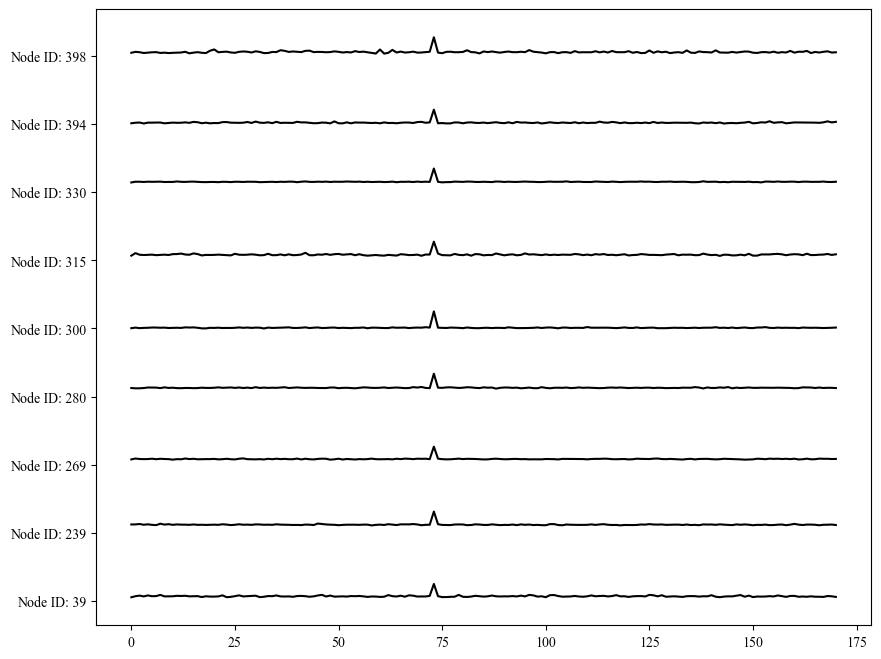

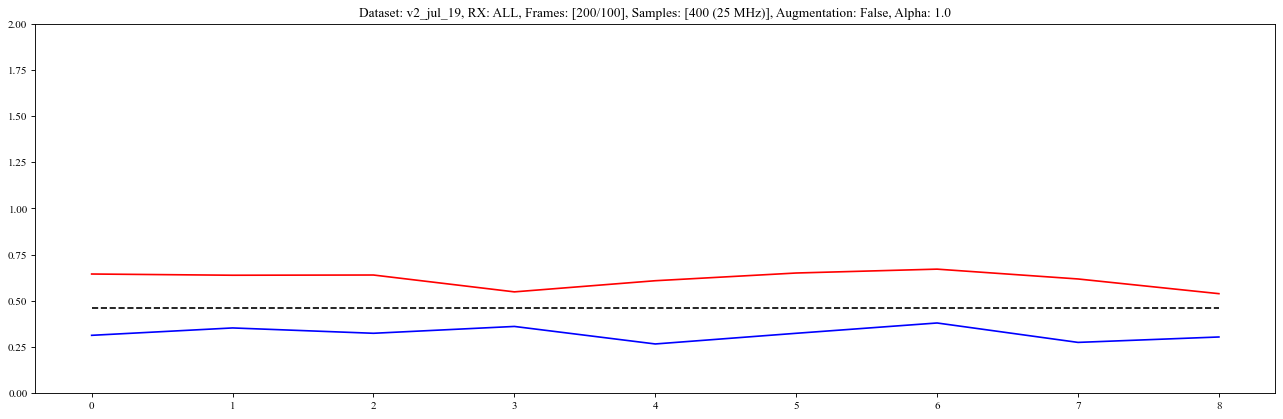

Matlab.quit


In [22]:
np.random.seed(1)

# RX_NODES = ['node1-1', 'node1-20', 'node19-19']
RX_NODES = ['node1-1', 'node1-20', 'node20-1', 'node19-19']
DATASETS = ['v1_jul_13', 'v2_jul_19', 'v2_jul_21', 'v3_aug_8']

try:
    aug_on = False
    show_fp_heatmaps = False
    show_training_history = True

    experiment_configs = []
    for rx_node in RX_NODES:
        data_config = {
            'dataset_name': DATASETS[1],
            'rx_name': rx_node,
            'frame_count_train': 200, # 200 for v2, 500 for v3
            'frame_count_epoch': 100,
            'samples_count': 400
        }
        aug_config = {
            'multiplier': 5,
            't_rms_bounds': matlab.double([1, 2]),
            'd_f_bounds': matlab.double([0, 10]),
            'k_factor_bounds': matlab.double([0, 10]),
            'awgn': matlab.double([10, 50]),
        }
        model_config = {
            'batch_size': 32,
            # 'loss_type': 'triplet_loss', 'loss_num_neg': 1,
            'loss_type': 'quadruplet_loss', 'loss_num_neg': 2,
            #  'loss_type': 'quintuplet_loss', 'loss_num_neg': 3,
            # 'loss_type': 'n_loss', 'loss_num_neg': 2,
            'npair_type': 'samedev',
            # 'npair_type': 'diffdev',
            'alpha': 1.0, # used only for triple & quadruple loss
            'patience': 10,
            'fp_len': 512,
            'row': 50,
            'col': 14
        }
        experiment_configs.append((data_config, aug_config, model_config))

    # Dataset v2_jul_19
    # node_ids_epoch_override=[1, 20, 39, 239, 269, 280, 300, 315, 330, 394, 398] # node1-1, node1-20
    # node_ids_epoch_override=[1, 10, 39, 239, 269, 280, 300, 315, 330, 394, 398] # node20-1
    node_ids_epoch_override=[39, 239, 269, 280, 300, 315, 330, 394, 398] # universally accepted
    epochs_override = None

    # Dataset v2_jul_21
    # node_ids_epoch_override = [39, 239, 269, 280, 300, 315, 394, 398]

    # Dataset v3_aug_8
    # node_ids_epoch_override=[1, 259, 10, 269, 398, 247, 280, 186, 315, 189] # devices that work for all epochs
    # node_ids_epoch_override=[1, 259, 10, 394, 269, 270, 398, 273, 280, 39, 300, 186, 315, 189, 330, 209, 219, 247, 379, 252] # maximum reach
    # epochs_override = [ # these epochs let us test maximum number of nodes
    #     'epoch_2024-08-09_17-44-31',
    #     'epoch_2024-08-09_09-45-28',
    #     'epoch_2024-08-09_06-24-29',
    #     'epoch_2024-08-09_13-14-55',
    #     'epoch_2024-08-09_09-15-25',
    #     'epoch_2024-08-09_01-12-19',
    #     'epoch_2024-08-08_19-59-37',
    #     'epoch_2024-08-08_20-33-18',
    #     'epoch_2024-08-09_03-34-38',
    #     'epoch_2024-08-08_19-19-27',
    #     'epoch_2024-08-09_04-30-31',
    #     'epoch_2024-08-09_00-15-50',
    #     'epoch_2024-08-09_04-59-00',
    #     'epoch_2024-08-08_23-15-19',
    #     'epoch_2024-08-09_08-47-08',
    #     'epoch_2024-08-08_21-40-14',
    #     'epoch_2024-08-09_11-16-36',
    #     'epoch_2024-08-08_21-04-40',
    #     'epoch_2024-08-09_14-40-55',
    #     'epoch_2024-08-09_03-05-59',
    #     'epoch_2024-08-09_16-11-55',
    #     'epoch_2024-08-08_22-45-31',
    #     'epoch_2024-08-09_10-46-06',
    #     'epoch_2024-08-08_22-15-27',
    #     'epoch_2024-08-09_05-56-24',
    #     'epoch_2024-08-09_17-14-46',
    #     'epoch_2024-08-09_10-15-26',
    #     'epoch_2024-08-09_15-41-02',
    #     'epoch_2024-08-09_19-53-51',
    #     'epoch_2024-08-09_19-21-11',
    #     'epoch_2024-08-09_05-27-49']

    models = []
    histories = []
    for experiment_config in experiment_configs:
        data_config, aug_config, model_config = experiment_config
        
        print(f"Training extractor for {data_config['rx_name']}...")
        model, history = run_training(data_config, model_config, aug_config, aug_on)

        models.append(model)
        histories.append(history)

    # model, history = run_training(data_config, model_config, aug_config, aug_on)

    # for single_rx_id in np.arange(-1, len(RX_NODES)):
    for single_rx_id in [-1]:
        if single_rx_id == -1:
            fp_distances, plot_title = run_fingerprinting_all(RX_NODES, models, experiment_configs, node_ids_epoch_override, epochs_override, aug_on, show_fp_heatmaps)
        else: 
            fp_distances, plot_title = run_fingerprinting_single(models[single_rx_id], experiment_configs[single_rx_id][0], experiment_configs[single_rx_id][2], node_ids_epoch_override, epochs_override, aug_on, show_fp_heatmaps)

        lower_line_max = max(fp_distances[:, 0])
        higher_line_min = min(fp_distances[:, 1])

        fp_threshold = (higher_line_min - lower_line_max) / 2 + lower_line_max

        # Create a figure with two subplots side by side
        plt.figure(figsize=(20, 6), dpi=80)
        plt.plot(fp_distances[:, 0], color='blue', label="Top 1st Fingerprint Similarity")
        plt.plot(fp_distances[:, 1], color='red', label="Top 2nd Fingerprint Similarity")
        plt.plot([0, len(fp_distances)-1], [fp_threshold, fp_threshold], label="New Device Detection Threshold", color="black", linestyle="--")
        plt.ylim(0, 2)
        plt.title(plot_title)
        plt.show()
except Exception as e:
    print(e)
finally:
    print('Matlab.quit')

In [18]:
import numpy as np

length = 300

row = 50
num_column = int(np.floor((length-row)/(row/2) + 1) - 1)

print(f"{row}x{num_column}")

50x10
